# Galaxy Clustering Algorithm!

- Use VFS galaxies! Fortunately, I have not deleted my catalog of galaxies...
- What data?
    - Maybe feed in either CIGALE or GALFIT output parameters?
    - Measure curves of growth??
- Use PCA for dimensionality reduction
- Then...UNSUPERVISED LEARNING! I.E., find natural groupings in the data without pre-defined labels
- And then...interpret. Is there any physical meaning associated with the clusters?
    - Morphology? 
        - May have to perform some visual inspection
        - Could also try statmorph?
    - Environment?
        - vf_v2_environment.fits flags

### To begin, I will need some features
- A few thoughts:
    - NUV-r, FUV-NUV, W1-W3, g-r, W1-W2 colors
    - CIGALE sSFR, Mstar, A_V
    - GALFIT nser (W1), nser (W3), axis ratio (W1), size ratio (W3/W1)
    - W1 luminosity
- Will have to 'standardize' these features for clustering
    - ensures all features contribute equally regardless of their original units and scales

In [ ]:
from astropy.table import Table
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
%matplotlib inline
import os
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [ ]:
#pull the data; tidy the data; isolate the features; normalize (or log?) the features
cigale = Table.read('data/cigale_vf_metallicity.fits')
galfit_w1 = Table.read('data/vf_v2_galfit_W1-fixBA.fits')
galfit_w3 = Table.read('data/vf_v2_galfit_W3-fixBA.fits')
phot = Table.read('data/vf_v2_legacy_ephot.fits')
environment = Table.read('data/vf_v2_environment.fits')   #for later

In [ ]:
#cannot have a convolved model which GALFIT has flagged as unreliable...and there is no data in the row,
#which I interpret as the central x pixel being zero.
galfit_quality_check = (~galfit_w1['CNumerical_Error']) & (~galfit_w3['CNumerical_Error']) & \
                       (galfit_w1['CXC']>0) & (galfit_w3['CXC']>0) & \
                       (galfit_w1['CN']<=6) & (galfit_w3['CN']<=6)

In [ ]:
#add CIGALE quality check
#just be sure no empty stellar ass rows
cigale_quality_check = (cigale['bayes.stellar.m_star']>0)

In [ ]:
#add legacy photometry quality check
#amounts to making sure none of the columns we need have empty cells
phot_quality_check = (phot['FLUX_AP03_NUV']>0) & (phot['FLUX_AP03_FUV']>0) & \
                     (phot['FLUX_AP03_R']>0) & (phot['FLUX_AP03_W3']>0) & \
                     (phot['FLUX_AP01_G']>0) & (phot['FLUX_AP01_R']>0) & \
                     (phot['FLUX_SB25_W1']>0) & (phot['FLUX_SB23_W1']>0)

In [ ]:
#defining and applying flags
full_flag = galfit_quality_check #& cigale_quality_check & phot_quality_check
cigale = cigale[full_flag]
galfit_w1 = galfit_w1[full_flag]
galfit_w3 = galfit_w3[full_flag]
phot = phot[full_flag]
environment = environment[full_flag]

---

In [ ]:
##############
# photometry #
##############

#converting to magnitudes, then calculating colors
NUV_R = -2.5*np.log10(phot['FLUX_AP03_NUV']/phot['FLUX_AP03_R']) # SF history
FUV_NUV = -2.5*np.log10(phot['FLUX_AP03_FUV']/phot['FLUX_AP03_NUV']) # Recent SF + dust
G_R = -2.5*np.log10(phot['FLUX_AP03_G']/phot['FLUX_AP03_R']) # Optical color
W1_W2 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W2']) # AGN diagnostic
W1_W3 = -2.5*np.log10(phot['FLUX_AP03_W1']/phot['FLUX_AP03_W3']) # SF/AGN activity

#g-r color gradient from nearest to farthest relative to galaxy center
num = (phot['FLUX_AP01_G']/phot['FLUX_AP01_R'])
den = (phot['FLUX_AP08_G']/phot['FLUX_AP08_R'])
color_gradient = num / den

#some W1 surface brightness concentration because why not
concentration_W1 = phot['FLUX_SB23_W1'] / phot['FLUX_SB25_W1']  # Higher = more concentrated

In [ ]:
##########
# GALFIT #
##########

nser_w1 = galfit_w1['CN']
nser_w3 = galfit_w3['CN']
ba_w1 = phot['BA_MOMENT']
size_ratio = np.log10(galfit_w3['CRE']/galfit_w1['CRE'])
mag_w1 = galfit_w1['CMAG']
mag_w3 = galfit_w3['CMAG']

In [ ]:
##########
# CIGALE #
##########

logmstar = np.log10(cigale['bayes.stellar.m_star'])
logssfr = np.log10(cigale['bayes.sfh.sfr']) - np.log10(logmstar)
Av_attenuation = cigale['bayes.attenuation.Av_ISM']
fracAGN = cigale['bayes.agn.fracAGN']

---

---

## K-means!
- Pure field, pure group, and pure cluster only

## K-means automated

In [1]:
#from galfit_kmeans import galfit_kmeans
from galfit_kmeans import *

#set colors=False to use the default GALFIT set of features (Sersic index, effective radius)
#df_scaled = galfit_kmeans(colors=False)

#colors=True will include the following color magnitudes from JM's SGA2020 photometry:
    # NUV-r
    # W1-W3
#df_scaled = galfit_kmeans(colors=False)

NOTE: be sure to edit galfit_parameters.py so parameters are to your liking!

Using average g and r effective radius!

Using average W1 and W2 effective radius!

USING THESE FEATURES: ['CRE_W3-fixBA', 'CRE_W4', 'CN_g', 'CN_r', 'CN_W1-fixBA', 'CN_W2', 'CN_W3-fixBA', 'CN_W4', 
'AVG_RE_gr', 'AVG_RE_W1W2', 'NUV_r', 'W1_W4']

##############################################################

...

##############################################################

IQR clipping (k=1.5): Removing an additional 427/1030 outliers (41.5%)

Remaining galaxies: 603

FEATURE CLUSTER MEDIAN PROPERTIES:

CRE_W3-fixBA_unscaled  CRE_W4_unscaled  CN_g_unscaled  \
Feature Cluster                                                          
0                                3.528            3.507          0.887   
1                                1.942            1.278          1.610   
2                                1.659            0.940          0.887   

                 CN_r_unscaled  CN_W1-fixBA_unscaled  CN_W2_unscaled  \
Feature Cluster                                                        
0                        1.057                 1.013           0.902   
1                        1.611                 1.498           1.192   
2                        0.965                 0.874           0.723   

                 CN_W3-fixBA_unscaled  CN_W4_unscaled  AVG_RE_gr_unscaled  \
Feature Cluster                                                             
0                               0.626           0.412               4.797   
1                               0.941           0.908               3.094   
2                               0.575           0.465               2.051   

                 AVG_RE_W1W2_unscaled  NUV_r_unscaled  W1_W4_unscaled  \
Feature Cluster                                                         
0                               3.746           2.632           0.725   
1                               2.231           2.621           0.810   
2                               1.815           2.279           0.874   

                 Size Ratio  
Feature Cluster              
0                      0.95  
1                      0.85  
2                      0.91

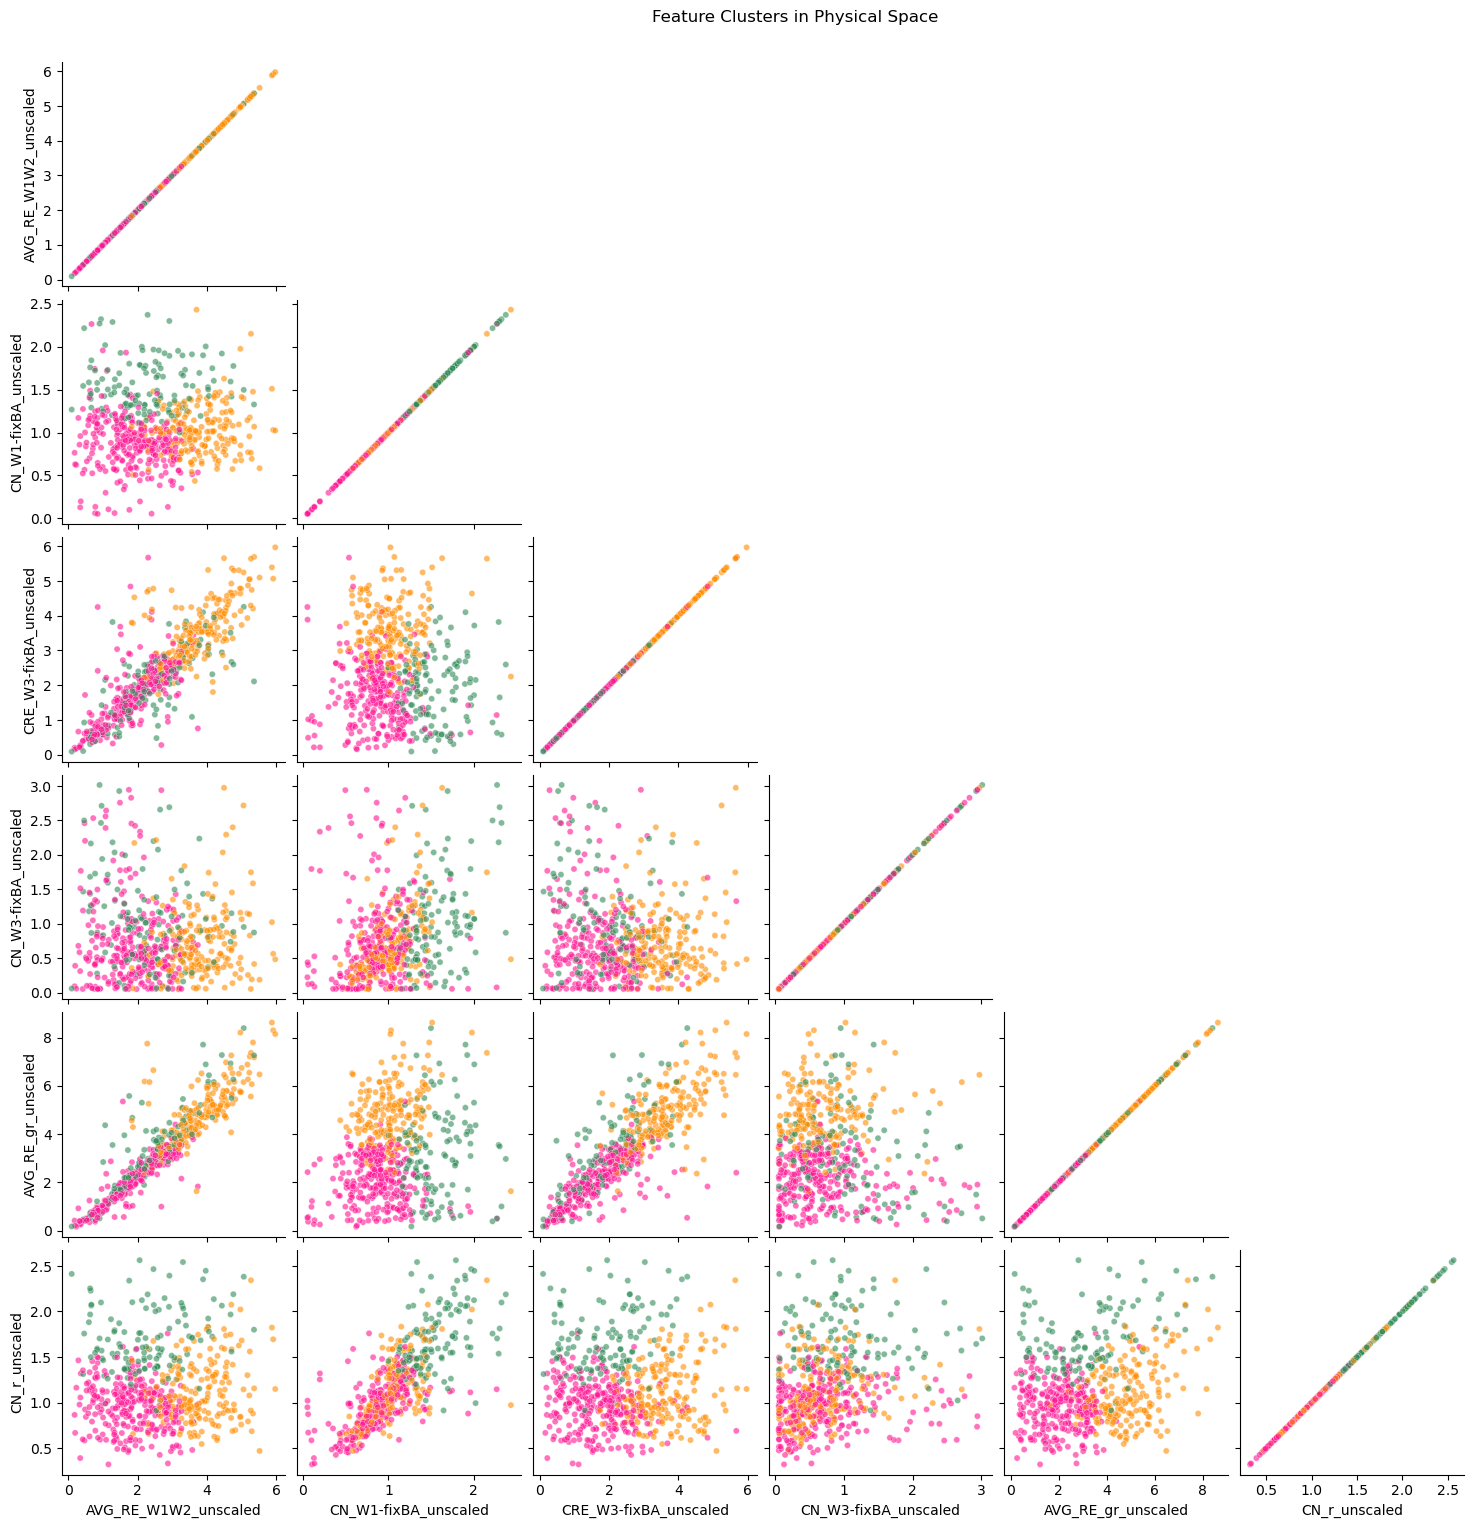

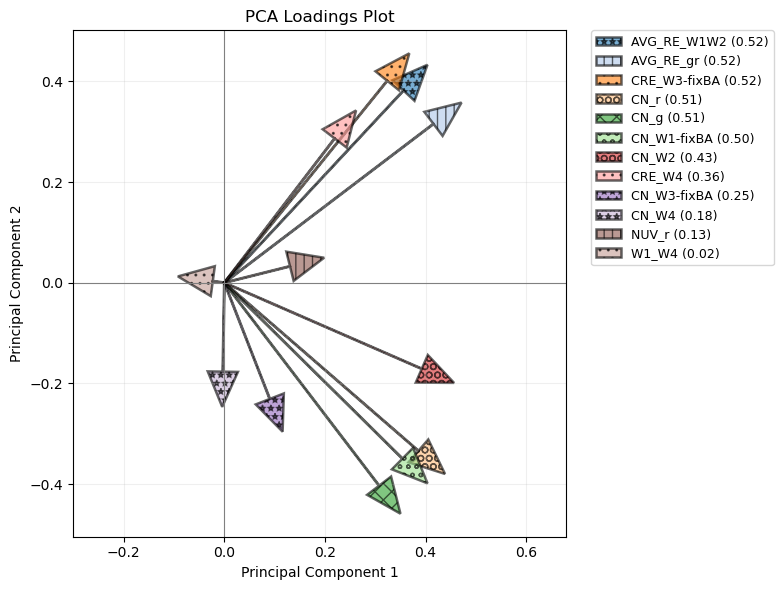

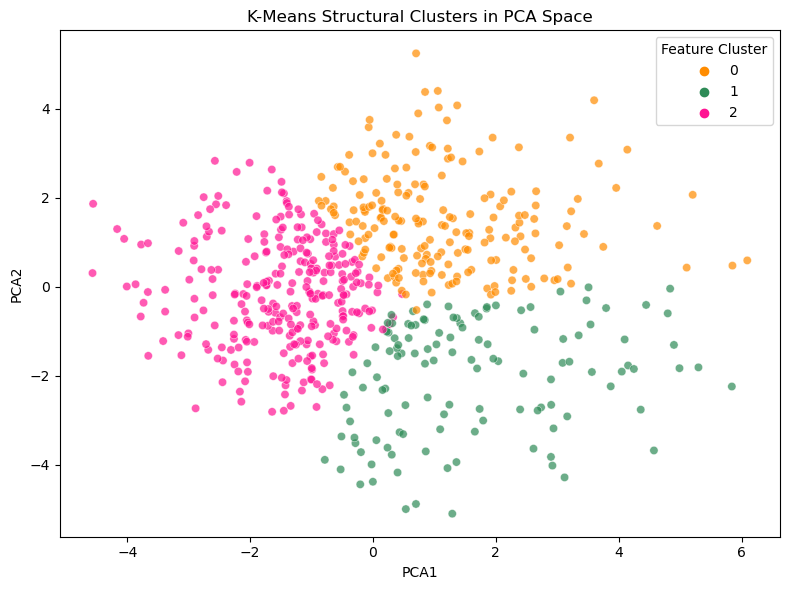

In [2]:
df_scaled_colors = galfit_kmeans(colors=True, flux=False)

Text(0, 0.5, 'log(SFR)')

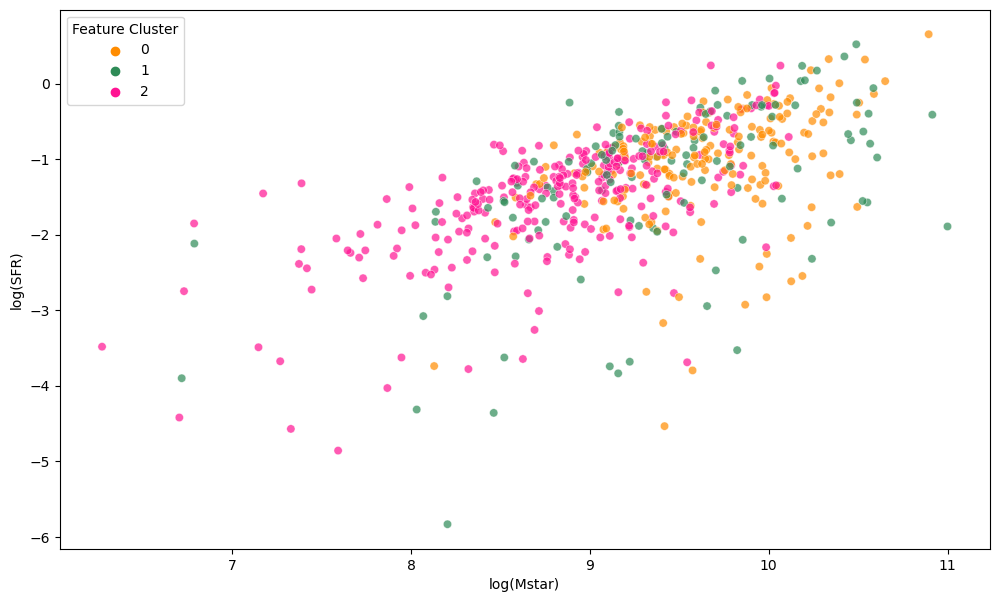

In [50]:
mstar=df_scaled_colors['logmstar']
sfr=df_scaled_colors['logsfr']
cluster=df_scaled_colors['Feature Cluster']

from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
plt.figure(figsize=(12,7))
sns.scatterplot(data=df_scaled_colors, x=mstar, y=sfr, hue='Feature Cluster',
            palette=['darkorange','seagreen','deeppink'], alpha=0.7, edgecolor='w', linewidth=0.4)
plt.xlabel('log(Mstar)')
plt.ylabel('log(SFR)')